In [47]:
import pandas as pd
import numpy as np



In [48]:
df = pd.read_csv("../dataset/raw/spam.csv", encoding="ISO-8859-1")


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [50]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [51]:
df.sample()

,v1,v2
2802,spam,FreeMsg>FAV XMAS TONES!Reply REAL


In [52]:
#renaming the column
df.rename(columns={'v1':'target','v2':'text'},inplace=True)

In [53]:
df.sample()

,target,text
518,ham,That way transport is less problematic than on...


In [54]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [55]:
df['target'] = encoder.fit_transform(df['target'])
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [56]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [57]:
df.duplicated().sum()

np.int64(403)

In [58]:
df = df.drop_duplicates(keep="first")

In [59]:
df.duplicated().sum()

np.int64(0)

In [60]:
# Save as a standard, readable CSV
df.to_csv('../dataset/processed/spam_cleaned.csv', index=False)

In [61]:
# EDA
df.head()


,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [62]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

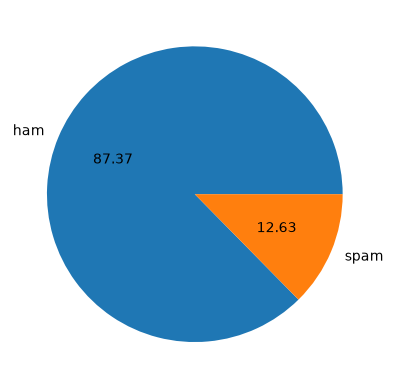

In [63]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct='%0.2f')
plt.show()

In [64]:
#data is imbalanced
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /home/sarthak/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/sarthak/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [65]:
df['num_character'] = df['text'].apply(len)
df.head()

,target,text,num_character
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [66]:
#fetch number of word

df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [67]:

df.head()

,target,text,num_character,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [68]:
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
df.head()

,target,text,num_character,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [69]:
df[['num_character','num_words','num_sentences']].describe()

,num_character,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [70]:
# this is for ham
df[df['target'] == 0] [['num_character','num_words','num_sentences']].describe()

,num_character,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [71]:
# this is for spam
df[df['target'] == 1] [['num_character','num_words','num_sentences']].describe()

,num_character,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [72]:
import seaborn as sns


<Axes: xlabel='num_character', ylabel='Count'>

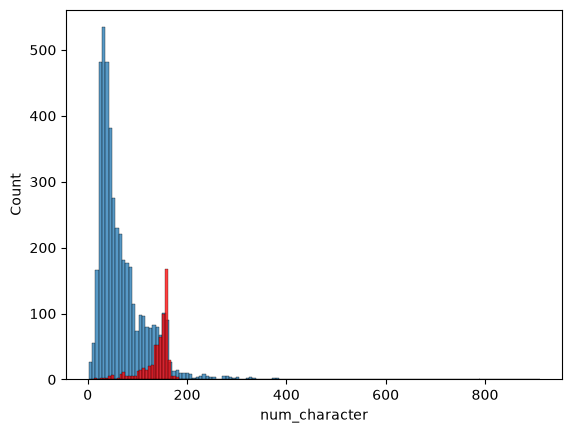

In [73]:
sns.histplot(df[df['target'] == 0]['num_character'])
sns.histplot(df[df['target'] == 1]['num_character'], color = 'red')

<Axes: xlabel='num_words', ylabel='Count'>

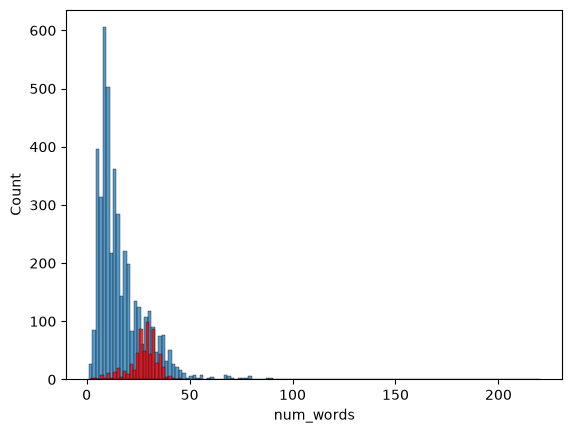

In [74]:
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'], color = 'red')

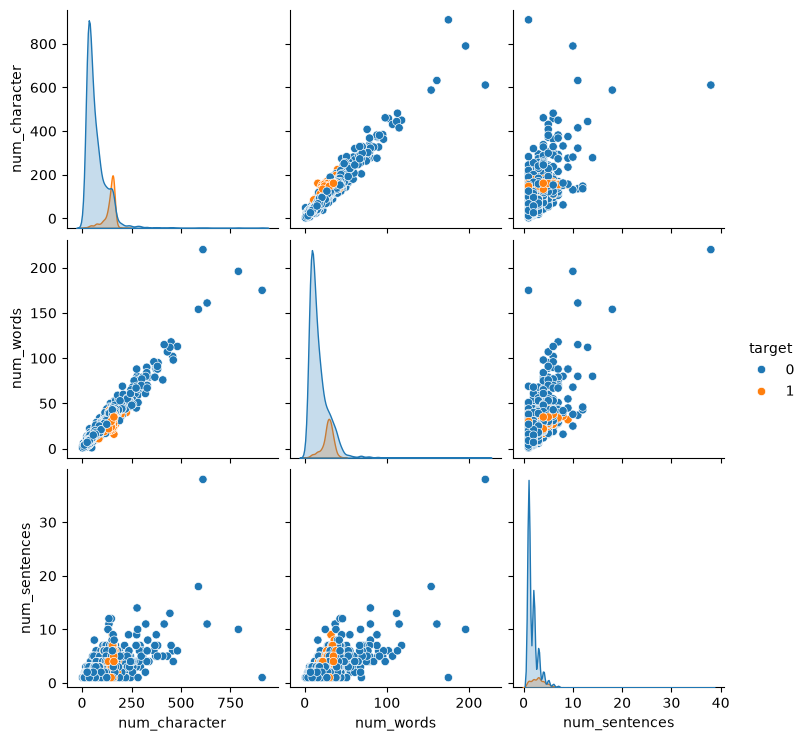

In [75]:
sns.pairplot(df, hue='target')

<Axes: >

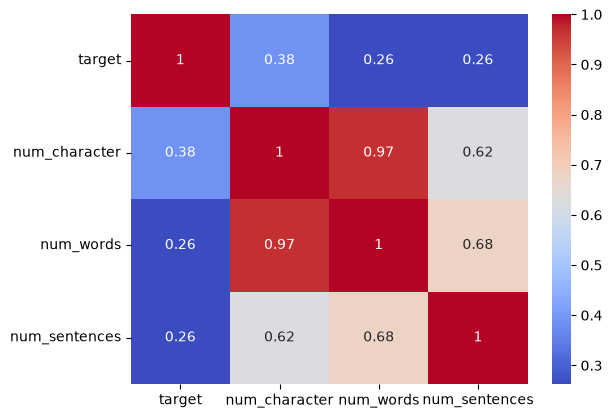

In [76]:
# Pass numeric_only=True to ignore the text columns
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

3.Data Preprocessing
    Lower case
    Tokenization
    Removing special characters
    Removing stop words and punctuation
    stemming

In [77]:
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('punkt')
nltk.download('stopwords')

ps = PorterStemmer()
stop_words = set(stopwords.words('english'))  # Create once

def transform_text(text):
    # Lowercase
    text = text.lower()

    # Tokenize
    words = nltk.word_tokenize(text)

    # Remove non-alphanumeric
    words = [word for word in words if word.isalnum()]

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Stem words
    words = [ps.stem(word) for word in words]

    return " ".join(words)

[nltk_data] Downloading package punkt to /home/sarthak/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/sarthak/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [78]:
df['transformed_text'] = df['text'].apply(transform_text)
df.head()

,target,text,num_character,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [79]:
from wordcloud import WordCloud
wc = WordCloud(width=800, height=400, min_font_size=10, background_color='white')



In [80]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

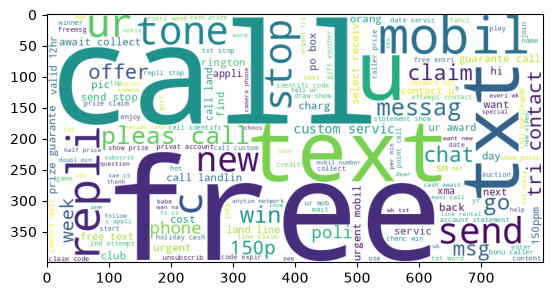

In [81]:
plt.imshow(spam_wc)

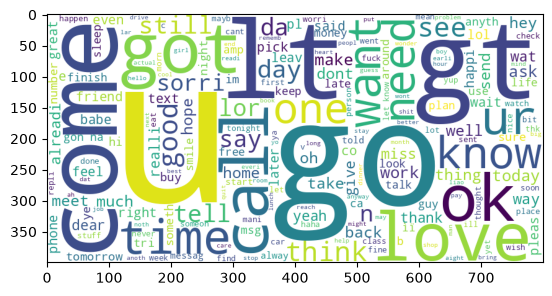

In [82]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))
plt.imshow(ham_wc)

In [83]:
spam_corpus = []

# Fixed column name to 'transformed_text' and method to .append()
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [84]:
len(spam_corpus)

9939

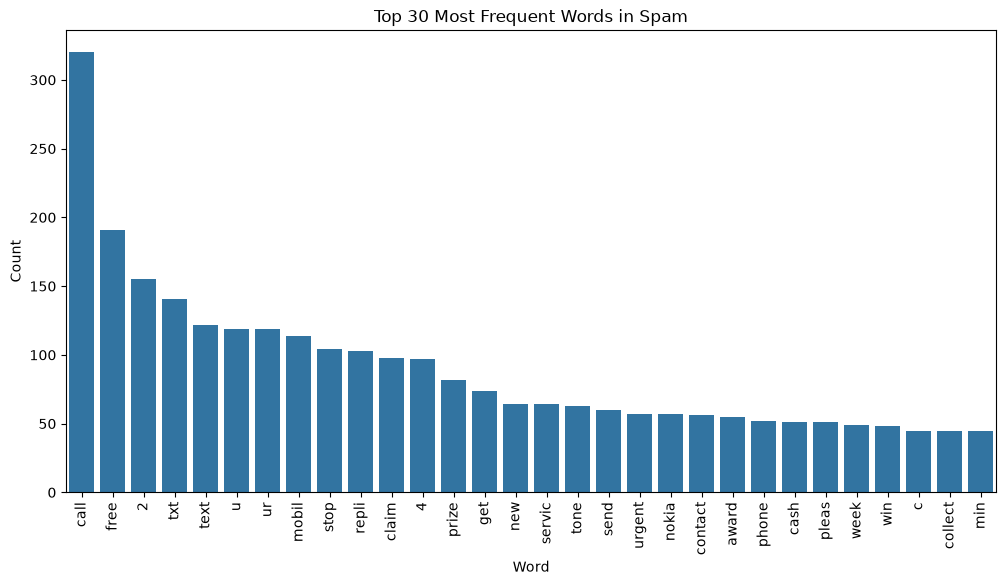

In [85]:
from collections import Counter

# 1. Create a clean DataFrame with explicit column names
top_words_df = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['Word', 'Count'])

# 2. Tell seaborn exactly what goes on X and Y
plt.figure(figsize=(12, 6))
sns.barplot(x='Word', y='Count', data=top_words_df)

# 3. Rotate the labels vertically so they don't overlap
plt.xticks(rotation='vertical')

plt.title('Top 30 Most Frequent Words in Spam')
plt.show()

In [86]:
ham_corpus = []

# Fixed column name to 'transformed_text' and method to .append()
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [87]:
len(ham_corpus)

35404

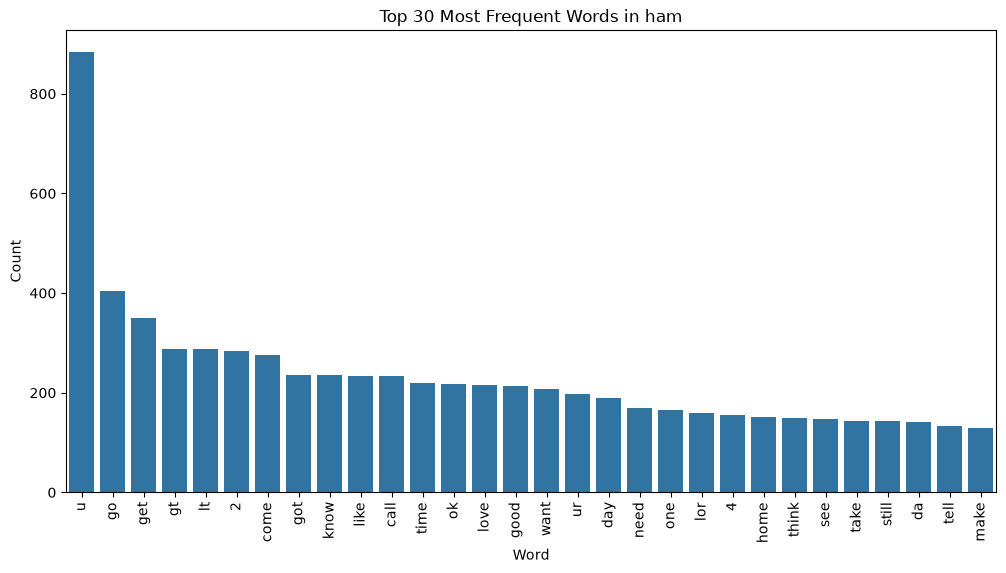

In [88]:
from collections import Counter

# 1. Create a clean DataFrame with explicit column names
top_words_df = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['Word', 'Count'])

# 2. Tell seaborn exactly what goes on X and Y
plt.figure(figsize=(12, 6))
sns.barplot(x='Word', y='Count', data=top_words_df)

# 3. Rotate the labels vertically so they don't overlap
plt.xticks(rotation='vertical')

plt.title('Top 30 Most Frequent Words in ham')
plt.show()

In [89]:
df.head()

,target,text,num_character,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [90]:
df.to_csv('../dataset/processed/model_train.csv')

Model Building

In [91]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer()

In [92]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [93]:
X.shape


(5169, 6708)

In [94]:
y = df['target'].values

In [95]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [96]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [97]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [98]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8762088974854932
[[793 103]
 [ 25 113]]
0.5231481481481481


In [99]:
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9593810444874274
[[896   0]
 [ 42  96]]
1.0


In [100]:
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9700193423597679
[[893   3]
 [ 28 110]]
0.9734513274336283


we chosse tfid --> mnb

In [102]:
import joblib

joblib.dump(mnb,'../models/model.pkl')

['../models/model.pkl']